In [ ]:
!pip install -q scikit-learn
!pip install timm

import os
import glob
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (confusion_matrix,ConfusionMatrixDisplay,classification_report,roc_curve,auc,roc_auc_score)

In [ ]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/עיבוד תמונה בכלים של למידה עמוקה-חן וירין/project/Histological_Data"

benign_folder = os.path.join(base_path, "Benign")
malignant_folder = os.path.join(base_path, "Malignant")

In [ ]:
data = []


def extract_patient_id(filename):

    filename = filename.replace("Copy of ", "")

    match = re.search(
        r'-(\d+-[A-Za-z0-9]+)-400',
        filename
    )

    if match:
        return match.group(1)

    else:
        raise ValueError(filename)



def add_folder(folder, label):

    images = glob.glob(
        os.path.join(folder, "*.png")
    )

    for path in images:

        filename = os.path.basename(path)

        patient = extract_patient_id(filename)

        data.append({
            "path": path,
            "label": label,
            "group": patient
        })


add_folder(benign_folder, 0)
add_folder(malignant_folder, 1)


df = pd.DataFrame(data)

df.head()

,path,label,group
0,/content/drive/MyDrive/עיבוד תמונה בכלים של למ...,0,14-22549AB
1,/content/drive/MyDrive/עיבוד תמונה בכלים של למ...,0,14-22549AB
2,/content/drive/MyDrive/עיבוד תמונה בכלים של למ...,0,14-22549AB
3,/content/drive/MyDrive/עיבוד תמונה בכלים של למ...,0,14-22549AB
4,/content/drive/MyDrive/עיבוד תמונה בכלים של למ...,0,14-22549AB


In [ ]:
print("Images:", len(df))
print("Patients:", df.group.nunique())

print("\nImages per class")
print(df.label.value_counts())

print("\nPatients per class")
print(df.groupby("label").group.nunique())

Images: 1831
Patients: 79

Images per class
label
1    1243
0     588
Name: count, dtype: int64

Patients per class
label
0    24
1    55
Name: group, dtype: int64


In [ ]:
gss = GroupShuffleSplit(n_splits=1,test_size=0.15,random_state=42)

train_val_idx, test_idx = next(gss.split(df,df["label"],groups=df["group"]))

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)

test_df = df.iloc[test_idx].reset_index(drop=True)

print("Train+Val images:", len(train_val_df))
print("Test images:", len(test_df))

print("\nTrain+Val classes")
print(train_val_df.label.value_counts())

print("\nTest classes")
print(test_df.label.value_counts())

Train+Val images: 1573
Test images: 258

Train+Val classes
label
1    1032
0     541
Name: count, dtype: int64

Test classes
label
1    211
0     47
Name: count, dtype: int64


In [ ]:
class BreastHistologyDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row.path
        ).convert("RGB")


        label = torch.tensor(
            row.label
        ).long()


        if self.transform:
            image = self.transform(image)


        return image, label

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize((128,128)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.RandomAffine(
        degrees=20,
        translate=(0.2, 0.2)   # up to 20% width and height shifts
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


test_transform = transforms.Compose([

    transforms.Resize((128,128)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [ ]:
def get_radimagenet_densenet():

    model = models.densenet121(
        weights=None
    )

    checkpoint = torch.load(
        "/content/drive/MyDrive/עיבוד תמונה בכלים של למידה עמוקה-חן וירין/project/DenseNet121.pt",
        map_location="cpu"
    )


    new_checkpoint = {}

    for key, value in checkpoint.items():

        new_key = key.replace(
            "backbone.0.",
            "features."
        )

        new_checkpoint[new_key] = value


    missing_keys, unexpected_keys = model.load_state_dict(
        new_checkpoint,
        strict=False
    )
    model.classifier = nn.Linear(model.classifier.in_features,2)



    print("Missing keys:")
    print(missing_keys)

    print("\nUnexpected keys:")
    print(unexpected_keys)
    return model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()


        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)


    loss = running_loss / len(loader)
    acc = correct / total

    return loss, acc

In [ ]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)


            outputs = model(images)

            loss = criterion(outputs, labels)


            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)


    loss = running_loss / len(loader)
    acc = correct / total


    return loss, acc

                                                path  label       group
0  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0  14-23060CD
1  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0   14-22549G
2  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0  14-21998AB
3  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0   14-22549G
4  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      0    14-16184
5  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      1    14-12312
6  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      1    14-11951
7  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      1    14-16601
8  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      1     14-5694
9  /content/drive/MyDrive/עיבוד תמונה בכלים של למ...      1  14-13418DE
Missing keys:
['classifier.weight', 'classifier.bias']

Unexpected keys:
[]
Epoch   1 | Loss = 0.6939 | Accuracy = 0.5000
Epoch   2 | Loss = 0.6931 | Accuracy = 0.6000
Epoch   3 | Loss = 0.6924 | Accuracy = 0

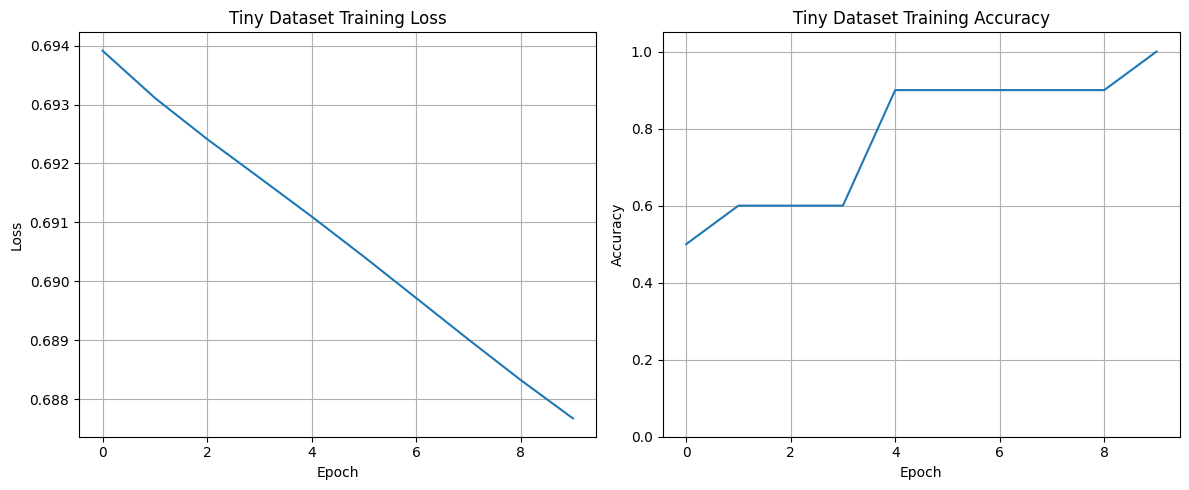

In [ ]:
tiny_df = pd.concat([
    train_val_df[train_val_df["label"] == 0].sample(5, random_state=42),
    train_val_df[train_val_df["label"] == 1].sample(5, random_state=42)
]).reset_index(drop=True)

print(tiny_df)

tiny_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

tiny_dataset = BreastHistologyDataset(
    tiny_df,
    transform=tiny_transform
)

tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=10,   # whole dataset in one batch
    shuffle=True
)

tiny_model = get_radimagenet_densenet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    tiny_model.parameters(),
    lr=1e-4
)

epochs = 100

losses = []
accuracies = []

for epoch in range(epochs):

    loss, acc = train_one_epoch(
        tiny_model,
        tiny_loader,
        optimizer,
        criterion,
        device
    )

    losses.append(loss)
    accuracies.append(acc)

    print(
        f"Epoch {epoch+1:3d} | "
        f"Loss = {loss:.4f} | "
        f"Accuracy = {acc:.4f}"
    )

    if acc >= 0.99:
        print("\nTiny dataset successfully memorized!")
        break

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].plot(losses)
axes[0].set_title("Tiny Dataset Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

axes[1].plot(accuracies)
axes[1].set_title("Tiny Dataset Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GroupKFold

fold_results = []
fold_models = []

gkf = GroupKFold(n_splits=5)
fold_history = []


for fold, (train_idx, val_idx) in enumerate(gkf.split(train_val_df,train_val_df["label"],groups=train_val_df["group"])):

    print("\n====================")
    print(f"FOLD {fold+1}")
    print("====================")

    train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
    val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

    print("Train images:", len(train_df))
    print("Validation images:", len(val_df))


    weights = compute_class_weight(class_weight="balanced",classes=np.unique(train_df["label"]),y=train_df["label"])

    weights = torch.tensor(weights,dtype=torch.float).to(device)

    print("Class weights:", weights)

    train_loader = DataLoader(BreastHistologyDataset(train_df,train_transform),batch_size=32,shuffle=True)

    val_loader = DataLoader(BreastHistologyDataset(val_df,test_transform),batch_size=32, shuffle=False)

    model = get_radimagenet_densenet().to(device)

    criterion = nn.CrossEntropyLoss(weight=weights)

    optimizer = torch.optim.Adam(model.parameters(),lr=1e-4)

    epochs = 50
    patience = 7   # number of epochs allowed without improvement
    best_val_loss = np.inf
    counter = 0

    best_path = f"fold_{fold+1}_best_model.pth"
    best_path = f"fold_{fold+1}_model.pth"
    best_val_loss = np.inf

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):

      train_loss, train_acc = train_one_epoch(
          model,
          train_loader,
          optimizer,
          criterion,
          device
      )


      val_loss, val_acc = evaluate(
          model,
          val_loader,
          criterion,
          device
      )


      # Save history for plots
      train_losses.append(train_loss)
      val_losses.append(val_loss)

      train_accs.append(train_acc)
      val_accs.append(val_acc)


      print(
          f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}"
      )


      # -------------------------
      # Early stopping logic
      # -------------------------

      if val_loss < best_val_loss:

          print("Validation loss improved")

          best_val_loss = val_loss
          counter = 0


          # Save best model
          torch.save(
              model.state_dict(),
              best_path
          )


      else:

          counter += 1

          print(
              f"No improvement ({counter}/{patience})"
          )


          if counter >= patience:

              print("Early stopping triggered")

              break
    fold_history.append({
    "fold": fold + 1,
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_acc": train_accs,
    "val_acc": val_accs
})




FOLD 1
Train images: 1255
Validation images: 318
Class weights: tensor([1.2992, 0.8128], device='cuda:0')
Missing keys:
['classifier.weight', 'classifier.bias']

Unexpected keys:
[]
Epoch 1/50 | Train Loss: 0.6924 | Train Acc: 0.6151 | Val Loss: 0.6786 | Val Acc: 0.8176
Validation loss improved
Epoch 2/50 | Train Loss: 0.6899 | Train Acc: 0.6167 | Val Loss: 0.6664 | Val Acc: 0.7547
Validation loss improved
Epoch 3/50 | Train Loss: 0.6836 | Train Acc: 0.6717 | Val Loss: 193.9557 | Val Acc: 0.6509
No improvement (1/7)
Epoch 4/50 | Train Loss: 0.6700 | Train Acc: 0.6924 | Val Loss: 4215.5076 | Val Acc: 0.6855
No improvement (2/7)
Epoch 5/50 | Train Loss: 0.6452 | Train Acc: 0.7139 | Val Loss: 14295.5318 | Val Acc: 0.7138
No improvement (3/7)
Epoch 6/50 | Train Loss: 0.6181 | Train Acc: 0.7139 | Val Loss: 24575.2783 | Val Acc: 0.7296
No improvement (4/7)
Epoch 7/50 | Train Loss: 0.5821 | Train Acc: 0.7410 | Val Loss: 34389.9610 | Val Acc: 0.7830
No improvement (5/7)
Epoch 8/50 | Train Los

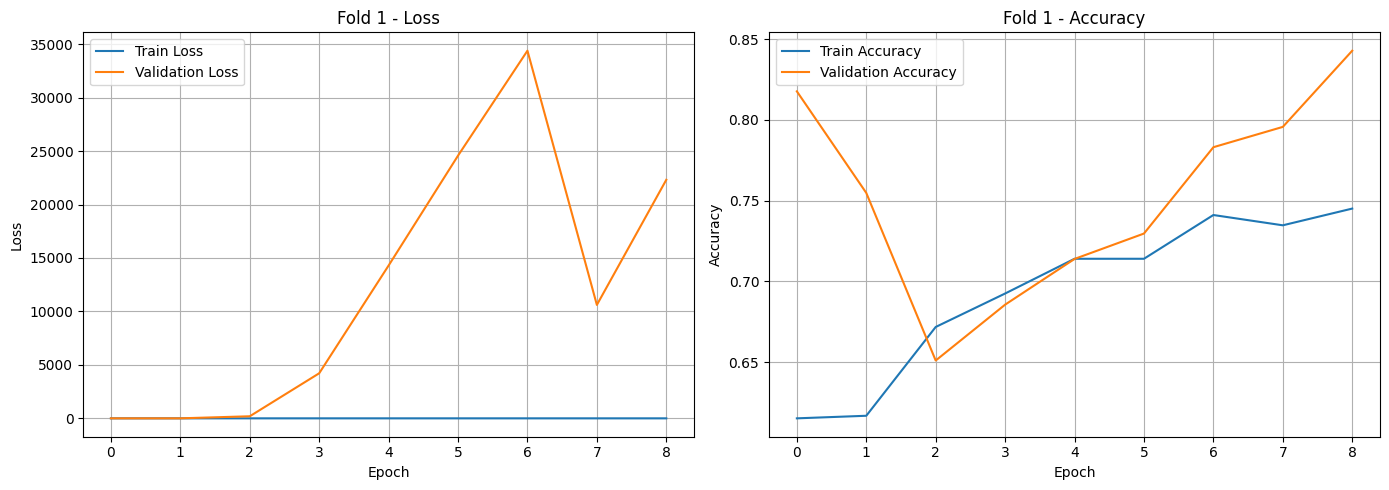

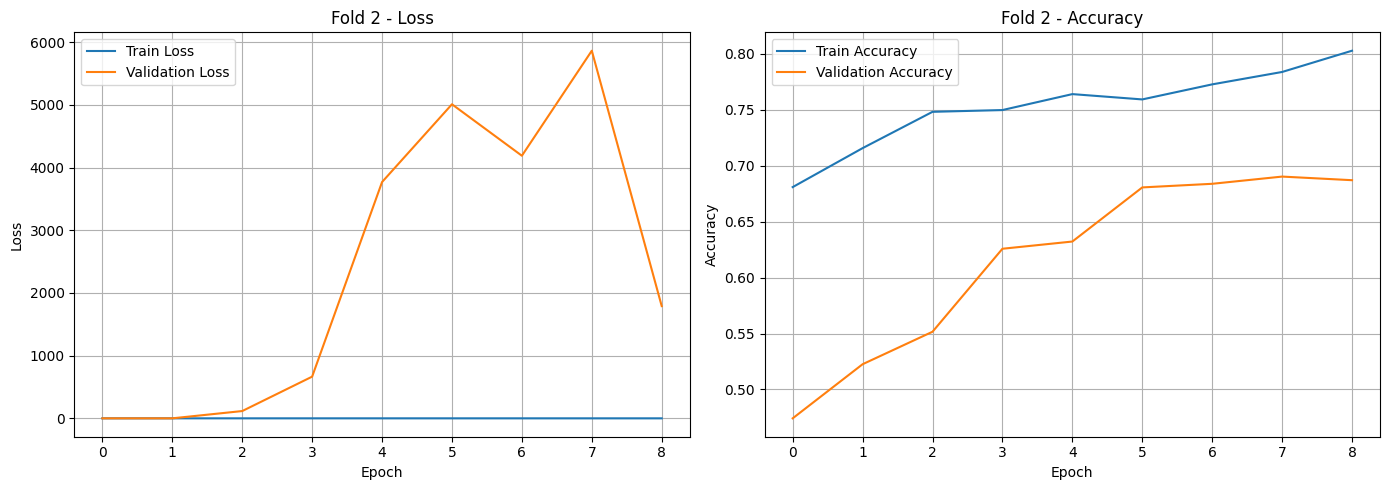

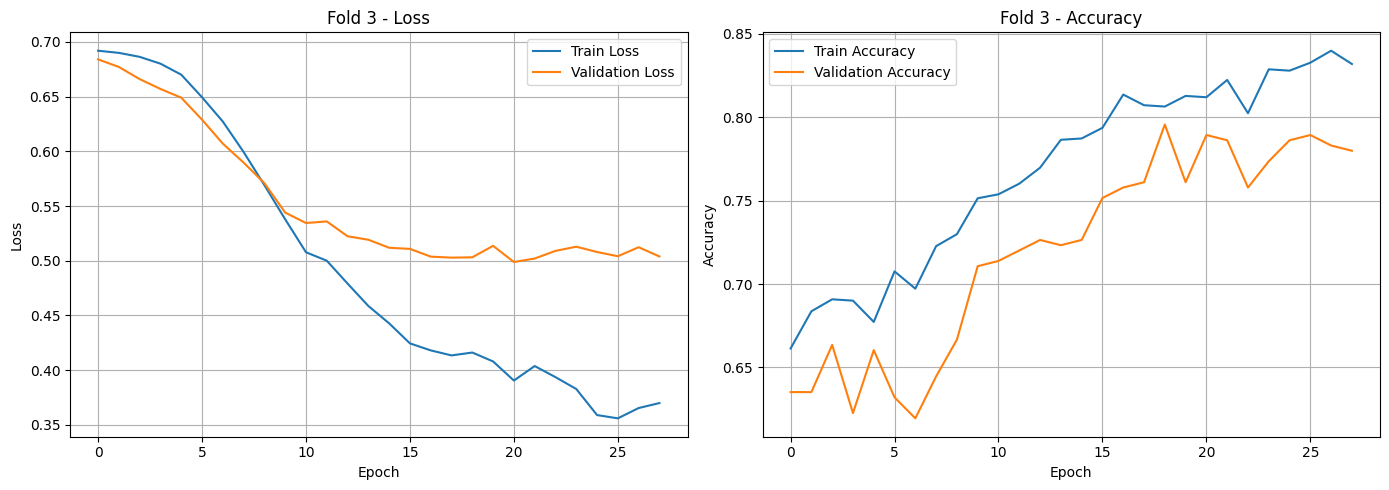

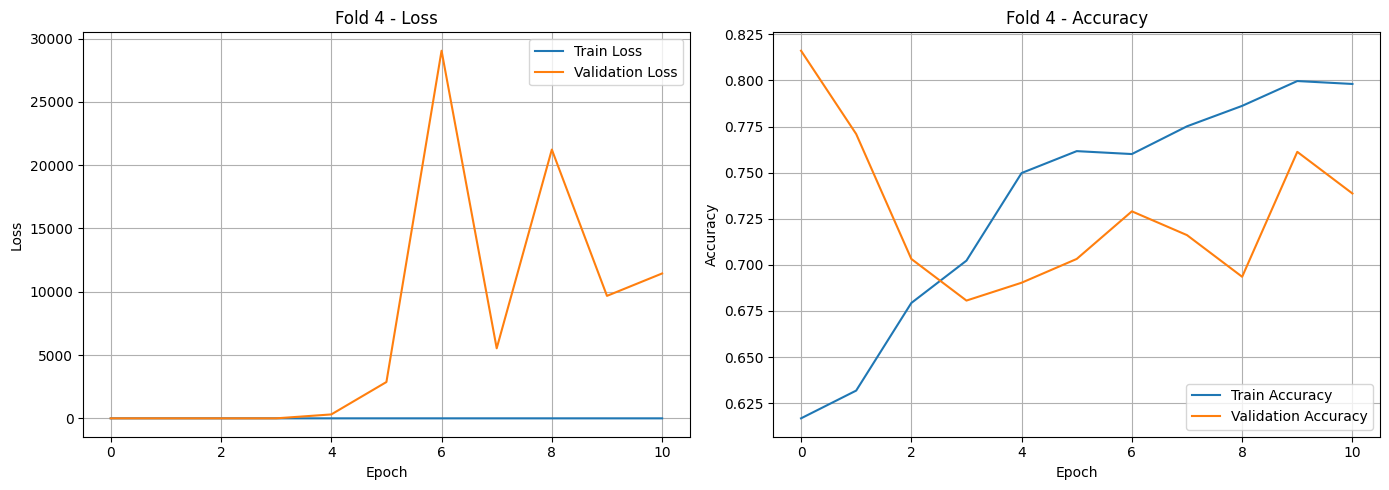

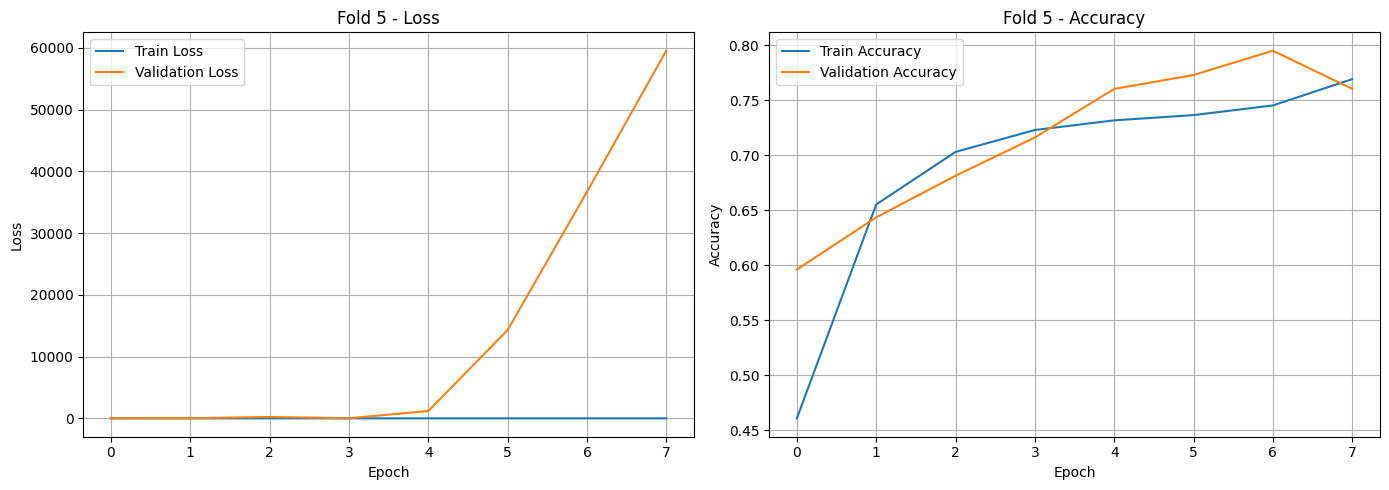

In [ ]:
for history in fold_history:

    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 5)
    )

    # -------------------------
    # Loss subplot
    # -------------------------
    axes[0].plot(
        history["train_loss"],
        label="Train Loss"
    )

    axes[0].plot(
        history["val_loss"],
        label="Validation Loss"
    )

    axes[0].set_title(
        f"Fold {history['fold']} - Loss"
    )

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")

    axes[0].legend()
    axes[0].grid(True)


    # -------------------------
    # Accuracy subplot
    # -------------------------
    axes[1].plot(
        history["train_acc"],
        label="Train Accuracy"
    )

    axes[1].plot(
        history["val_acc"],
        label="Validation Accuracy"
    )

    axes[1].set_title(
        f"Fold {history['fold']} - Accuracy"
    )

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")

    axes[1].legend()
    axes[1].grid(True)


    plt.tight_layout()
    plt.show()

In [ ]:
final_train_dataset = BreastHistologyDataset(
    train_val_df,
    transform=train_transform
)

final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

In [ ]:
test_dataset = BreastHistologyDataset(
    test_df,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

In [ ]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_val_df["label"]),
    y=train_val_df["label"]
)

weights = torch.tensor(
    weights,
    dtype=torch.float
).to(device)

print(weights)

tensor([1.4538, 0.7621], device='cuda:0')


In [ ]:
final_model = get_radimagenet_densenet()
final_model = final_model.to(device)

Missing keys:
['classifier.weight', 'classifier.bias']

Unexpected keys:
[]


In [ ]:
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=1e-4
)

In [ ]:
epochs = 20

train_losses = []
train_accs = []

for epoch in range(epochs):

    train_loss, train_acc = train_one_epoch(
        final_model,
        final_train_loader,
        optimizer,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {train_loss:.4f} | "
        f"Accuracy: {train_acc:.4f}"
    )

Epoch 1/50 | Loss: 0.6920 | Accuracy: 0.4876
Epoch 2/50 | Loss: 0.6878 | Accuracy: 0.6745
Epoch 3/50 | Loss: 0.6779 | Accuracy: 0.6999
Epoch 4/50 | Loss: 0.6521 | Accuracy: 0.7292
Epoch 5/50 | Loss: 0.6135 | Accuracy: 0.7298
Epoch 6/50 | Loss: 0.5734 | Accuracy: 0.7432
Epoch 7/50 | Loss: 0.5318 | Accuracy: 0.7565
Epoch 8/50 | Loss: 0.5079 | Accuracy: 0.7686
Epoch 9/50 | Loss: 0.4829 | Accuracy: 0.7781
Epoch 10/50 | Loss: 0.4675 | Accuracy: 0.7877
Epoch 11/50 | Loss: 0.4700 | Accuracy: 0.7826
Epoch 12/50 | Loss: 0.4408 | Accuracy: 0.8029
Epoch 13/50 | Loss: 0.4448 | Accuracy: 0.8036
Epoch 14/50 | Loss: 0.4420 | Accuracy: 0.8150
Epoch 15/50 | Loss: 0.4338 | Accuracy: 0.8163
Epoch 16/50 | Loss: 0.4265 | Accuracy: 0.8004
Epoch 17/50 | Loss: 0.4106 | Accuracy: 0.8220
Epoch 18/50 | Loss: 0.4118 | Accuracy: 0.8144
Epoch 19/50 | Loss: 0.3929 | Accuracy: 0.8290
Epoch 20/50 | Loss: 0.3964 | Accuracy: 0.8296
Epoch 21/50 | Loss: 0.3723 | Accuracy: 0.8398
Epoch 22/50 | Loss: 0.3840 | Accuracy: 0.83

In [ ]:
torch.save(
    final_model.state_dict(),
    "DenseNet121_BreaKHis_final.pth"
)

print("Final model saved.")

Final model saved.


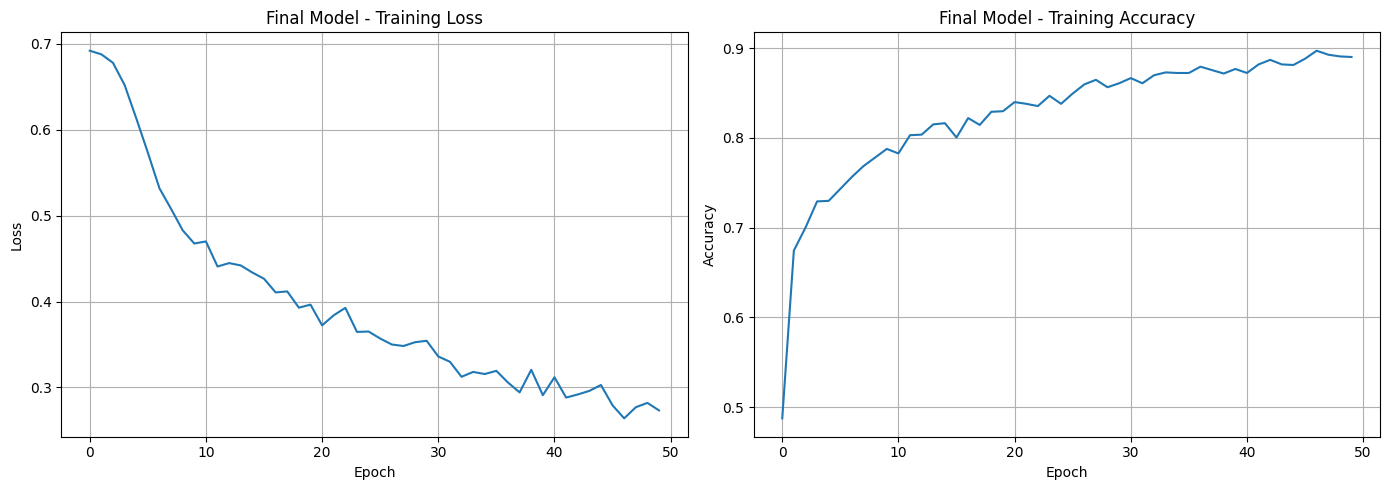

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses)
axes[0].set_title("Final Model - Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Accuracy
axes[1].plot(train_accs)
axes[1].set_title("Final Model - Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    auc
)

final_model.eval()

running_loss = 0

y_true = []
y_pred = []
y_scores = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = final_model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item()

        probabilities = torch.softmax(outputs, dim=1)

        predictions = torch.argmax(probabilities, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

        # Probability of the malignant class (label = 1)
        y_scores.extend(probabilities[:, 1].cpu().numpy())

test_loss = running_loss / len(test_loader)

test_accuracy = np.mean(np.array(y_true) == np.array(y_pred))

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.9823
Test Accuracy: 0.8295


<Figure size 600x600 with 0 Axes>

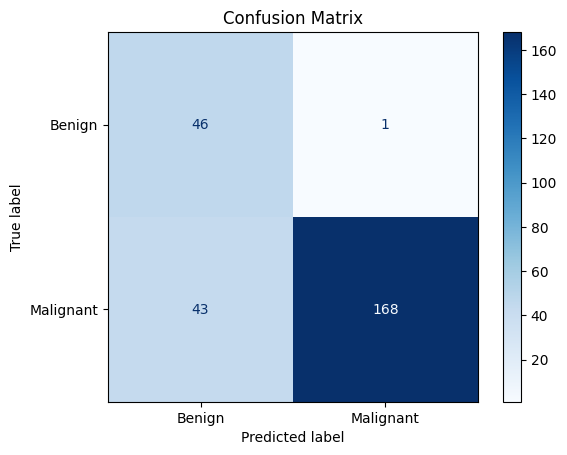

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

plt.figure(figsize=(6,6))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.52      0.98      0.68        47
   Malignant       0.99      0.80      0.88       211

    accuracy                           0.83       258
   macro avg       0.76      0.89      0.78       258
weighted avg       0.91      0.83      0.85       258



In [ ]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")

Sensitivity : 0.7962
Specificity : 0.9787


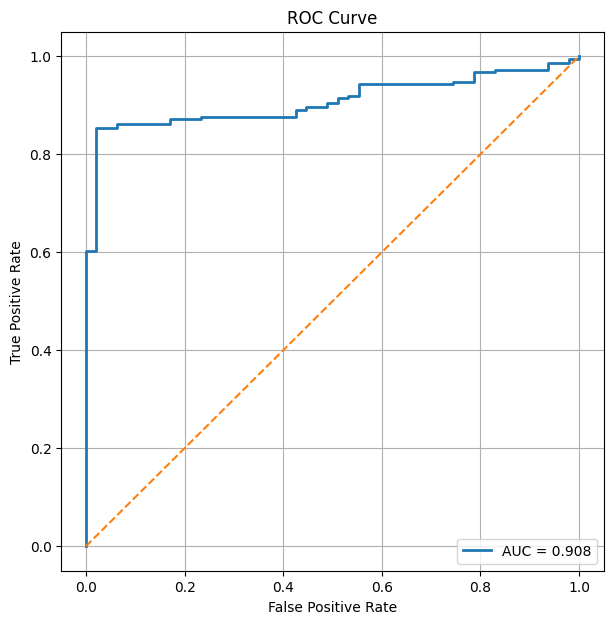

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

In [ ]:
roc_auc = roc_auc_score(y_true, y_scores)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9083


In [ ]:
precision = tp / (tp + fp)
recall = sensitivity
f1 = 2 * precision * recall / (precision + recall)

print("\n==============================")
print("Final Test Results")
print("==============================")
print(f"Loss         : {test_loss:.4f}")
print(f"Accuracy     : {test_accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Sensitivity  : {sensitivity:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"ROC-AUC      : {roc_auc:.4f}")
print("==============================")


Final Test Results
Loss         : 0.9823
Accuracy     : 0.8295
Precision    : 0.9941
Sensitivity  : 0.7962
Specificity  : 0.9787
F1-score     : 0.8842
ROC-AUC      : 0.9083
